# Toronto Robbery Open Data Analysis

This notebook reproduces the Excel analysis in Python using pandas, NumPy, and Matplotlib.
Goals:
- Clean and reorganize the Toronto robbery dataset
- Restrict analysis to 2014–2025
- Count distinct incidents using EVENT_UNIQUE_ID
- Recreate the main Excel PivotTables with groupby() and pivot_table()
- Create portfolio-ready charts and heatmaps

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

### 1. Load the dataset:

In [3]:
file_path = 'Robbery_Open_Data.csv'  # update if needed
df = pd.read_csv(file_path)

print('Rows:', len(df))
print('Columns:', len(df.columns))
df.head()

Rows: 40885
Columns: 31


,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,OCC_YEAR,OCC_MONTH,OCC_DAY,OCC_DOY,OCC_DOW,OCC_HOUR,DIVISION,LOCATION_TYPE,PREMISES_TYPE,UCR_CODE,UCR_EXT,OFFENCE,CSI_CATEGORY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
0,1,GO-20141262644,1/1/2014 5:00:00 AM,1/1/2014 5:00:00 AM,2014,January,1,1,Wednesday,14,2014.0,January,1.0,1.0,Wednesday,14,D12,"Apartment (Rooming House, Condo)",Apartment,1610,150,Robbery - Purse Snatch,Robbery,113,Weston (113),113,Weston (113),-79.516192,43.700155,-8.851702e+06,5.419157e+06
1,2,GO-20141262818,1/1/2014 5:00:00 AM,1/1/2014 5:00:00 AM,2014,January,1,1,Wednesday,14,2014.0,January,1.0,1.0,Wednesday,3,D51,Other Commercial / Corporate Places (For Profi...,Commercial,1610,210,Robbery - Business,Robbery,167,Church-Wellesley (167),075,Church-Yonge Corridor (75),-79.384137,43.663899,-8.837002e+06,5.413576e+06
2,3,GO-20141260912,1/1/2014 5:00:00 AM,1/1/2014 5:00:00 AM,2014,January,1,1,Wednesday,6,2014.0,January,1.0,1.0,Wednesday,4,D14,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,1610,100,Robbery With Weapon,Robbery,078,Kensington-Chinatown (78),078,Kensington-Chinatown (78),-79.401983,43.647598,-8.838988e+06,5.411068e+06
3,4,GO-20141260577,1/1/2014 5:00:00 AM,1/1/2014 5:00:00 AM,2014,January,1,1,Wednesday,4,2014.0,January,1.0,1.0,Wednesday,2,NSA,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,1610,200,Robbery - Mugging,Robbery,NSA,NSA,NSA,NSA,0.000000,0.000000,6.327780e-09,5.664924e-09
4,5,GO-20141260577,1/1/2014 5:00:00 AM,1/1/2014 5:00:00 AM,2014,January,1,1,Wednesday,4,2014.0,January,1.0,1.0,Wednesday,2,NSA,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,1610,180,Robbery - Swarming,Robbery,NSA,NSA,NSA,NSA,0.000000,0.000000,6.327780e-09,5.664924e-09


### 2. Keep the columns used in the Excel Report:

In [4]:
keep_columns = [
    'EVENT_UNIQUE_ID', 'OCC_DATE', 'OCC_YEAR', 'OCC_MONTH', 'OCC_DAY',
    'OCC_DOW', 'OCC_HOUR', 'DIVISION', 'LOCATION_TYPE', 'PREMISES_TYPE',
    'OFFENCE', 'HOOD_158', 'NEIGHBOURHOOD_158', 'LONG_WGS84', 'LAT_WGS84'
]

df = df[keep_columns].copy()
df.head()

,EVENT_UNIQUE_ID,OCC_DATE,OCC_YEAR,OCC_MONTH,OCC_DAY,OCC_DOW,OCC_HOUR,DIVISION,LOCATION_TYPE,PREMISES_TYPE,OFFENCE,HOOD_158,NEIGHBOURHOOD_158,LONG_WGS84,LAT_WGS84
0,GO-20141262644,1/1/2014 5:00:00 AM,2014.0,January,1.0,Wednesday,14,D12,"Apartment (Rooming House, Condo)",Apartment,Robbery - Purse Snatch,113,Weston (113),-79.516192,43.700155
1,GO-20141262818,1/1/2014 5:00:00 AM,2014.0,January,1.0,Wednesday,3,D51,Other Commercial / Corporate Places (For Profi...,Commercial,Robbery - Business,167,Church-Wellesley (167),-79.384137,43.663899
2,GO-20141260912,1/1/2014 5:00:00 AM,2014.0,January,1.0,Wednesday,4,D14,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,Robbery With Weapon,078,Kensington-Chinatown (78),-79.401983,43.647598
3,GO-20141260577,1/1/2014 5:00:00 AM,2014.0,January,1.0,Wednesday,2,NSA,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,Robbery - Mugging,NSA,NSA,0.000000,0.000000
4,GO-20141260577,1/1/2014 5:00:00 AM,2014.0,January,1.0,Wednesday,2,NSA,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,Robbery - Swarming,NSA,NSA,0.000000,0.000000


### 3. Clean and Reorganize the Data:

In [7]:
df['OCC_DATE'] = pd.to_datetime(df['OCC_DATE'], errors='coerce')
df['OCC_YEAR'] = pd.to_numeric(df['OCC_YEAR'], errors='coerce').astype('Int64')
df['OCC_DAY'] = pd.to_numeric(df['OCC_DAY'], errors='coerce').astype('Int64')
df['OCC_HOUR'] = pd.to_numeric(df['OCC_HOUR'], errors='coerce').astype('Int64')
df['LONG_WGS84'] = pd.to_numeric(df['LONG_WGS84'], errors='coerce')
df['LAT_WGS84'] = pd.to_numeric(df['LAT_WGS84'], errors='coerce')

df['DASHBOARD_YEAR'] = df['OCC_YEAR'].where(
    df['OCC_YEAR'].between(2014, 2025)
)

analysis_df = df[df['OCC_YEAR'].between(2014, 2025)].copy()

print('Analysis rows:', len(analysis_df))
print('Distinct incidents:', analysis_df['EVENT_UNIQUE_ID'].nunique())

Analysis rows: 39598
Distinct incidents: 31320


### 4. Basic data-quality checks:

In [9]:
quality_check = pd.DataFrame({
    'missing_values': analysis_df.isna().sum(),
    'unique_values': analysis_df.nunique(dropna=True)
}).sort_values('missing_values', ascending=False)

quality_check

,missing_values,unique_values
PREMISES_TYPE,1,7
LOCATION_TYPE,1,51
EVENT_UNIQUE_ID,0,31320
OCC_DATE,0,4364
OCC_DAY,0,31
OCC_DOW,0,7
OCC_YEAR,0,12
OCC_MONTH,0,12
DIVISION,0,18
OCC_HOUR,0,24


### 5. Robbery incidents by year:

In [10]:
incidents_by_year = (
    analysis_df.groupby('OCC_YEAR')['EVENT_UNIQUE_ID']
    .nunique()
    .reset_index(name='Distinct_Incidents')
)

incidents_by_year

,OCC_YEAR,Distinct_Incidents
0,2014,2998
1,2015,2870
2,2016,3048
3,2017,3214
4,2018,3055
5,2019,2960
6,2020,2215
7,2021,1802
8,2022,2207
9,2023,2424


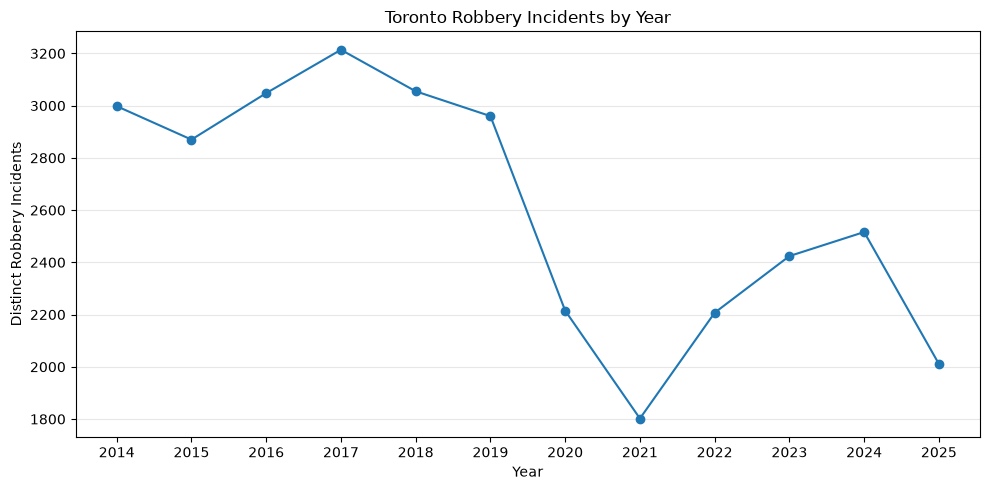

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(incidents_by_year['OCC_YEAR'], incidents_by_year['Distinct_Incidents'], marker='o')
plt.title('Toronto Robbery Incidents by Year')
plt.xlabel('Year')
plt.ylabel('Distinct Robbery Incidents')
plt.xticks(incidents_by_year['OCC_YEAR'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 6. Top 10 neighbourhoods by distinct robbery incidents:

In [12]:
top_neighbourhoods = (
    analysis_df[analysis_df['NEIGHBOURHOOD_158'].ne('NSA')]
    .groupby('NEIGHBOURHOOD_158')['EVENT_UNIQUE_ID']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

top_neighbourhoods

NEIGHBOURHOOD_158
Moss Park (73)                           1117
Downtown Yonge East (168)                 976
West Humber-Clairville (1)                717
Yonge-Bay Corridor (170)                  638
York University Heights (27)              632
Mount Olive-Silverstone-Jamestown (2)     585
Kensington-Chinatown (78)                 579
West Hill (136)                           554
Church-Wellesley (167)                    475
Annex (95)                                449
Name: EVENT_UNIQUE_ID, dtype: int64

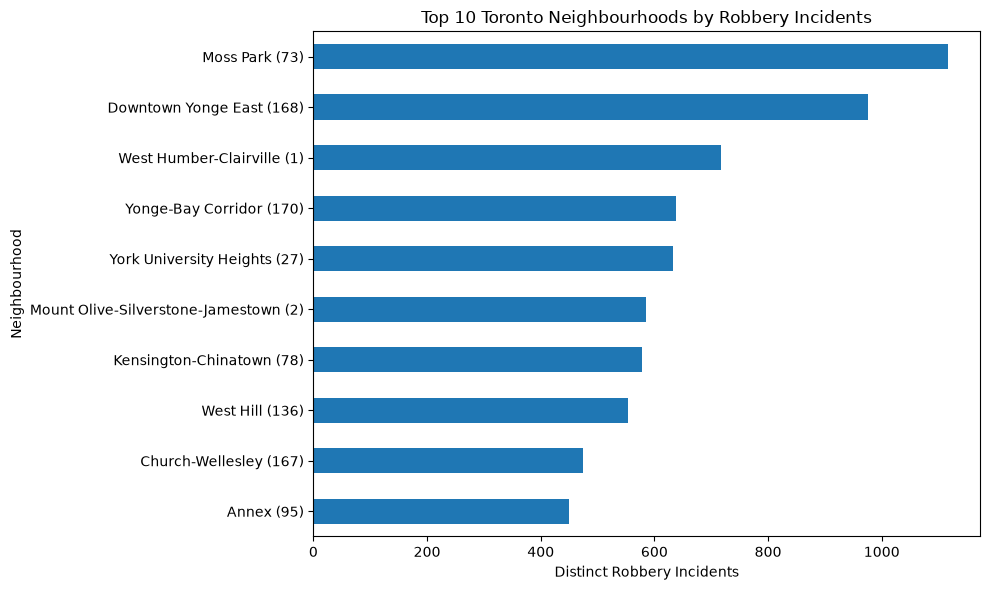

In [13]:
plt.figure(figsize=(10, 6))
top_neighbourhoods.sort_values().plot(kind='barh')
plt.title('Top 10 Toronto Neighbourhoods by Robbery Incidents')
plt.xlabel('Distinct Robbery Incidents')
plt.ylabel('Neighbourhood')
plt.tight_layout()
plt.show()

### 7. Year × Premises Type:

In [14]:
year_premises = pd.pivot_table(
    analysis_df,
    index='OCC_YEAR',
    columns='PREMISES_TYPE',
    values='EVENT_UNIQUE_ID',
    aggfunc=pd.Series.nunique,
    fill_value=0
)

year_premises

PREMISES_TYPE,Apartment,Commercial,Educational,House,Other,Outside,Transit
OCC_YEAR,,,,,,,
2014,271,546,111,65,49,1875,81
2015,287,604,70,76,60,1712,61
2016,236,711,96,80,56,1786,83
2017,295,785,87,82,89,1772,104
2018,244,864,74,70,79,1617,107
2019,245,802,77,87,82,1582,85
2020,158,789,45,62,90,980,91
2021,184,521,41,49,99,835,73
2022,186,681,46,69,183,955,87


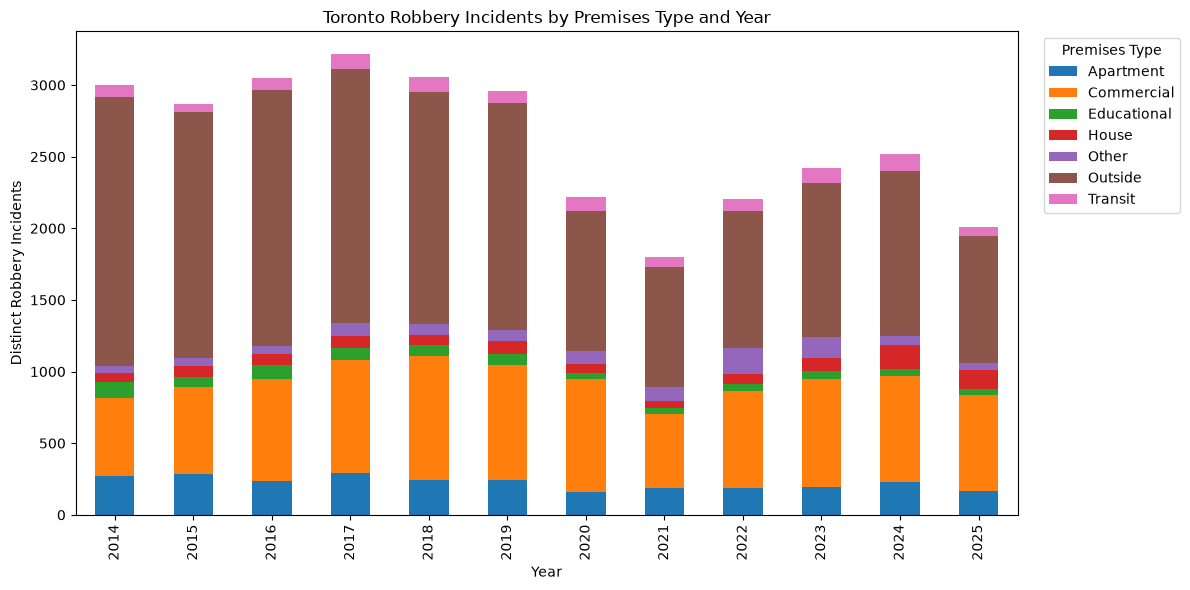

In [15]:
year_premises.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Toronto Robbery Incidents by Premises Type and Year')
plt.xlabel('Year')
plt.ylabel('Distinct Robbery Incidents')
plt.legend(title='Premises Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 8. Day of Week × Hour heatmap:

In [23]:
analysis_df['OCC_DOW'] = (
    analysis_df['OCC_DOW']
    .astype('string')
    .str.strip()
    .str.title()
)

In [24]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_hour = pd.pivot_table(
    analysis_df,
    index='OCC_DOW',
    columns='OCC_HOUR',
    values='EVENT_UNIQUE_ID',
    aggfunc='nunique',
    fill_value=0
)

day_hour = day_hour.reindex(day_order).fillna(0)

day_hour

OCC_HOUR,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
OCC_DOW,,,,,,,,,,,,,,,,,,,,,,,,
Monday,208,148,143,133,93,64,51,48,59,87,126,147,203,161,225,334,234,248,281,290,324,316,295,230
Tuesday,209,152,134,107,79,68,53,56,51,88,110,159,228,172,193,315,282,271,272,285,329,301,314,222
Wednesday,223,202,158,107,89,67,50,57,65,80,103,142,202,179,185,307,287,266,275,275,288,257,252,269
Thursday,204,180,159,121,81,54,64,49,60,77,131,142,215,167,216,315,263,245,290,299,300,311,270,253
Friday,239,207,155,149,116,79,54,47,70,79,108,161,227,173,226,324,306,260,297,289,328,355,290,321
Saturday,263,280,274,206,149,82,86,55,49,79,80,109,150,135,188,208,222,233,243,267,300,329,322,291
Sunday,287,280,234,237,128,95,68,47,54,51,65,84,109,110,146,196,198,224,227,257,286,275,238,215


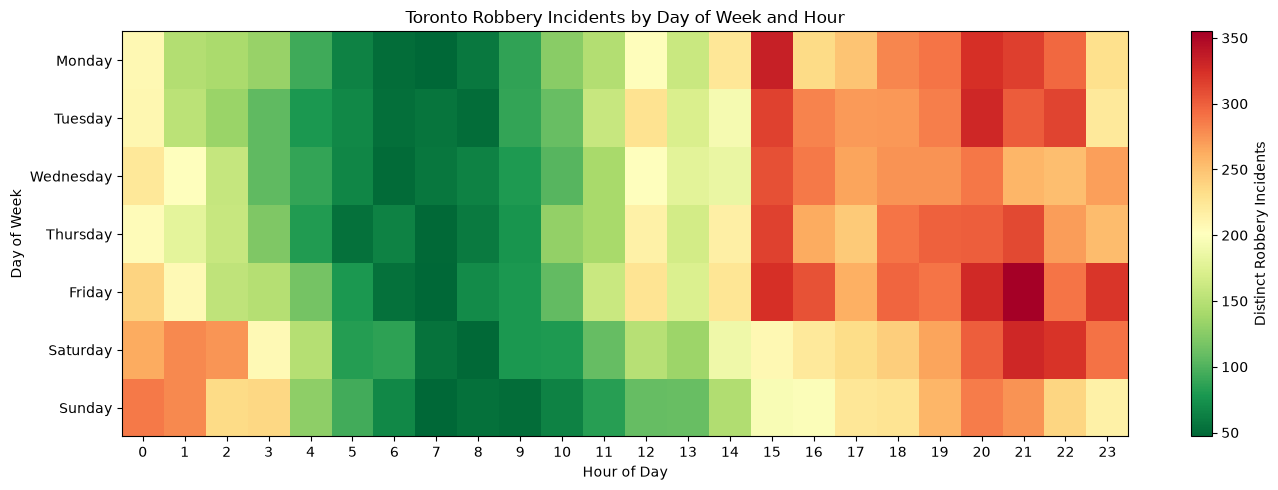

In [26]:
plt.figure(figsize=(14, 5))

plt.imshow(
    day_hour.values,
    aspect='auto',
    cmap='RdYlGn_r'   # low = green, high = red
)

plt.colorbar(label='Distinct Robbery Incidents')

plt.xticks(
    range(len(day_hour.columns)),
    day_hour.columns
)

plt.yticks(
    range(len(day_hour.index)),
    day_hour.index
)

plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.title('Toronto Robbery Incidents by Day of Week and Hour')

plt.tight_layout()
plt.show()

### 9. Offence Type × Premises Type:

In [27]:
offence_premises = pd.pivot_table(
    analysis_df,
    index='OFFENCE',
    columns='PREMISES_TYPE',
    values='EVENT_UNIQUE_ID',
    aggfunc=pd.Series.nunique,
    fill_value=0
)

offence_premises

PREMISES_TYPE,Apartment,Commercial,Educational,House,Other,Outside,Transit
OFFENCE,,,,,,,
Robbery - Armoured Car,6,14,2,0,1,17,4
Robbery - Atm,1,101,1,0,0,24,1
Robbery - Business,19,4426,0,3,517,67,29
Robbery - Delivery Person,91,19,2,15,9,191,0
Robbery - Financial Institute,3,945,1,1,1,7,0
Robbery - Home Invasion,582,30,0,456,9,4,0
Robbery - Mugging,586,766,308,119,162,6254,411
Robbery - Other,834,1008,207,180,189,3285,317
Robbery - Purse Snatch,60,100,7,21,16,897,77


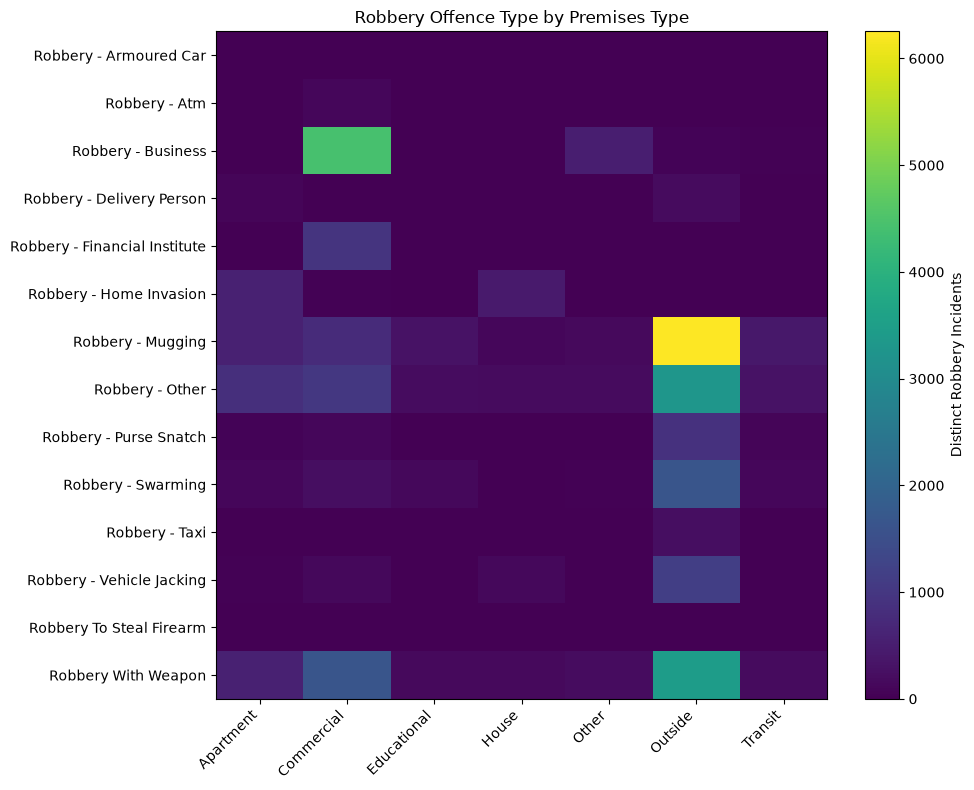

In [28]:
plt.figure(figsize=(10, 8))
plt.imshow(offence_premises.values, aspect='auto')
plt.colorbar(label='Distinct Robbery Incidents')
plt.xticks(range(len(offence_premises.columns)), offence_premises.columns, rotation=45, ha='right')
plt.yticks(range(len(offence_premises.index)), offence_premises.index)
plt.title('Robbery Offence Type by Premises Type')
plt.tight_layout()
plt.show()

### 10. Top neighbourhoods × major offence types:

In [29]:
major_offences = [
    'Robbery - Business',
    'Robbery - Mugging',
    'Robbery - Other',
    'Robbery - Purse Snatch',
    'Robbery - Swarming',
    'Robbery With Weapon'
]

top10_names = top_neighbourhoods.index.tolist()

neighbourhood_offence = pd.pivot_table(
    analysis_df[
        analysis_df['NEIGHBOURHOOD_158'].isin(top10_names) &
        analysis_df['OFFENCE'].isin(major_offences)
    ],
    index='NEIGHBOURHOOD_158',
    columns='OFFENCE',
    values='EVENT_UNIQUE_ID',
    aggfunc=pd.Series.nunique,
    fill_value=0
)

neighbourhood_offence

OFFENCE,Robbery - Business,Robbery - Mugging,Robbery - Other,Robbery - Purse Snatch,Robbery - Swarming,Robbery With Weapon
NEIGHBOURHOOD_158,,,,,,
Annex (95),99,120,88,21,33,75
Church-Wellesley (167),91,142,120,21,4,94
Downtown Yonge East (168),156,335,203,44,66,179
Kensington-Chinatown (78),90,178,133,37,26,108
Moss Park (73),68,464,315,40,29,187
Mount Olive-Silverstone-Jamestown (2),49,167,152,10,36,145
West Hill (136),63,167,140,18,35,84
West Humber-Clairville (1),184,138,119,24,35,166
Yonge-Bay Corridor (170),109,161,153,19,41,125


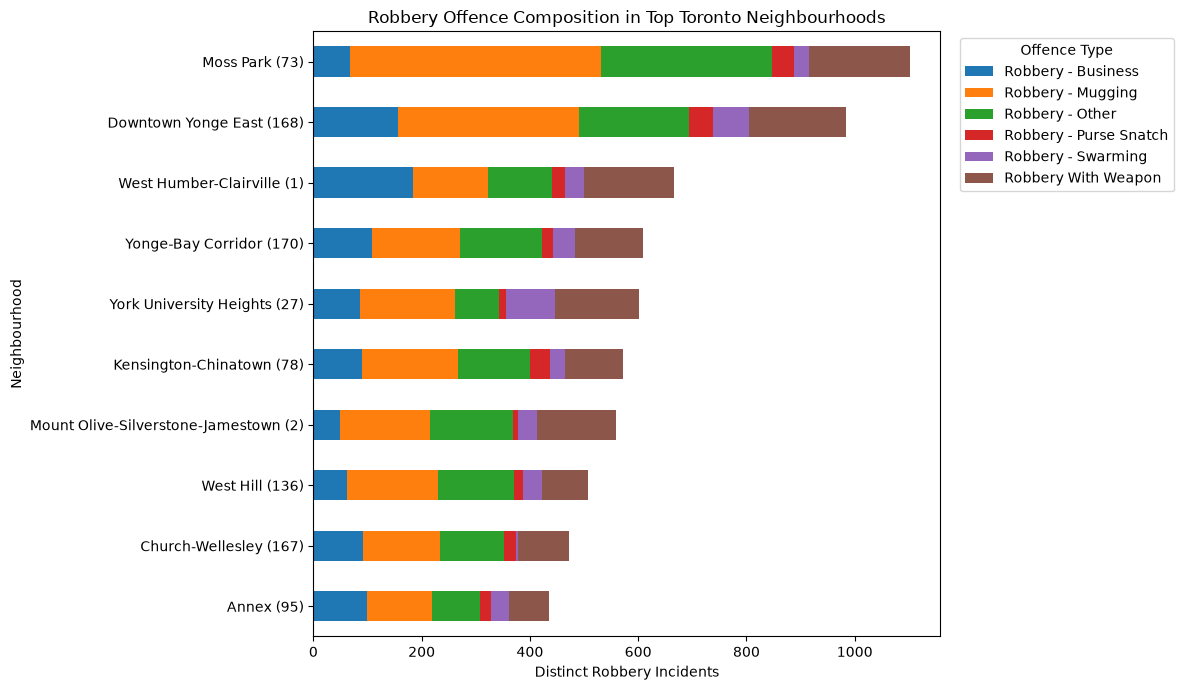

In [30]:
neighbourhood_offence['Total'] = neighbourhood_offence.sum(axis=1)
neighbourhood_offence = neighbourhood_offence.sort_values('Total', ascending=True)
plot_df = neighbourhood_offence.drop(columns='Total')

plot_df.plot(kind='barh', stacked=True, figsize=(12, 7))
plt.title('Robbery Offence Composition in Top Toronto Neighbourhoods')
plt.xlabel('Distinct Robbery Incidents')
plt.ylabel('Neighbourhood')
plt.legend(title='Offence Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 11. Top 5 Police Divisions × Year:

In [31]:
division_totals = (
    analysis_df.groupby('DIVISION')['EVENT_UNIQUE_ID']
    .nunique()
    .sort_values(ascending=False)
)

top5_divisions = division_totals.head(5).index.tolist()
division_totals.head(10)

DIVISION
D51    3363
D43    2532
D31    2325
D23    2199
D41    2157
D42    2141
D32    2130
D14    1867
D55    1784
D52    1775
Name: EVENT_UNIQUE_ID, dtype: int64

In [32]:
division_year = pd.pivot_table(
    analysis_df[analysis_df['DIVISION'].isin(top5_divisions)],
    index='OCC_YEAR',
    columns='DIVISION',
    values='EVENT_UNIQUE_ID',
    aggfunc=pd.Series.nunique,
    fill_value=0
)

division_year

DIVISION,D23,D31,D41,D43,D51
OCC_YEAR,,,,,
2014,202,215,259,286,291
2015,230,232,249,283,291
2016,280,229,217,239,298
2017,257,230,239,291,306
2018,194,236,199,200,401
2019,196,234,185,234,332
2020,117,153,147,150,320
2021,111,112,112,135,246
2022,144,165,137,156,222


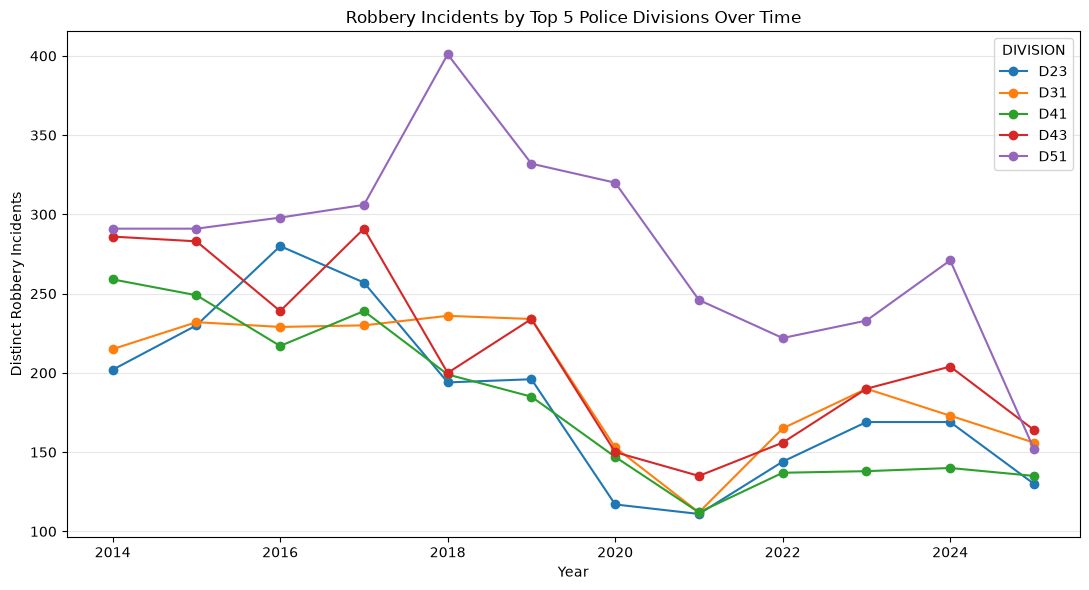

In [33]:
division_year.plot(figsize=(11, 6), marker='o')
plt.title('Robbery Incidents by Top 5 Police Divisions Over Time')
plt.xlabel('Year')
plt.ylabel('Distinct Robbery Incidents')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 12. Export cleaned data and analysis tables:

In [34]:
analysis_df.to_csv('Toronto_Robbery_Cleaned_2014_2025.csv', index=False)
incidents_by_year.to_csv('incidents_by_year.csv', index=False)
year_premises.to_csv('year_by_premises.csv')
day_hour.to_csv('day_by_hour.csv')
offence_premises.to_csv('offence_by_premises.csv')
neighbourhood_offence.to_csv('top_neighbourhoods_by_offence.csv')
division_year.to_csv('top5_divisions_by_year.csv')

### 13. Portfolio insights:

 - 2017 had the highest number of distinct robbery incidents with 3,214, while 2021 had the lowest with 1,802.
 - Incidents declined sharply from 2019 through 2021 before increasing again from 2022 to 2024.
 - Moss Park (73) had the highest number of robbery incidents among Toronto neighbourhoods with 1,117, followed by Downtown Yonge East (168) with 976 and West Humber-Clairville (1) with 717.
 - Outside locations were the most common premises type, accounting for 16,229 distinct incidents, followed by Commercial locations with 8,462. Together, these categories represented the majority of robbery incidents in the dataset.
 - Robbery incidents were generally lower during the early morning hours and higher during the afternoon and evening. The highest day/hour combination was Friday at 9 PM (21:00) with 355 distinct incidents.
 - Certain robbery types were strongly associated with particular premises. Robbery - Business was heavily concentrated in Commercial locations (4,426 incidents), while Robbery - Mugging was primarily associated with Outside locations (6,254). Home Invasion was concentrated mainly in Apartments (582) and Houses (456).
 - D51 had the highest number of incidents among police divisions, with 3,363 distinct incidents, followed by D43 (2,532) and D31 (2,325). D51 peaked at 401 incidents in 2018, then declined substantially, reaching 152 in 2025. The other leading divisions also generally showed lower incident counts after 2019, particularly during 2020–2021.